<a href="https://colab.research.google.com/github/Abdo404Khaled/IMISToolExeA/blob/main/Report/IMISToolA2026_Report4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: 202620863
* Name: ABDELRAHMAN KHALED MOHAMED MAHMOUD
* Colab account: mado4335@gmail.com

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---


---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



## 4A-0. Plan

The task has two halves, and the hint says to unite two things that were already shown separately
in the tutorials:

1. **A classifier.** I train a small convolutional network on **MNIST** (28x28 grayscale handwritten
   digits, 10 classes). MNIST is chosen over CIFAR-10 because a camera photo of a digit written on
   paper can be mapped onto MNIST's own format (white strokes on a black background) with a few
   lines of image processing, so the "capture -> recognize" loop actually works in practice.
2. **The camera.** The webcam snippet is the one used in `700/701_PyPorchPractice.ipynb`
   (`take_photo`, from the Colab code-snippet gallery): it opens the browser webcam in the output
   area, saves one JPEG, and returns its path. I connect its output directly to the classifier, so
   the recognition result is printed immediately after the shutter.

The glue between the two is a **preprocessing function**, which is where all the real work is:
a photo is a large, colour, dark-on-light image, while MNIST is a 28x28 light-on-dark image whose
digit is cropped to a 20x20 box and centred by centre of mass. Section 4A-3 does exactly that.

### 4A-1. Setup and data

In [1]:
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available():
    device = "cuda"                       # Colab T4
elif torch.backends.mps.is_available():
    device = "mps"                        # local Apple-Silicon GPU
else:
    device = "cpu"
print("PyTorch", torch.__version__, "| device =", device)

PyTorch 2.11.0+cu128 | device = cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


train images = 60000, test images = 10000


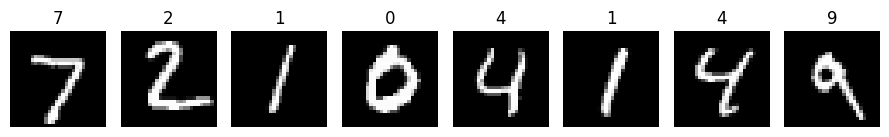

In [2]:
# MNIST is downloaded once and cached under ./data
MEAN, STD = 0.1307, 0.3081          # the standard MNIST statistics

train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # a little robustness
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

train_set = datasets.MNIST("./data", train=True,  download=True, transform=train_tf)
test_set  = datasets.MNIST("./data", train=False, download=True, transform=test_tf)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=512, shuffle=False)

print(f"train images = {len(train_set)}, test images = {len(test_set)}")

# look at the data before trusting it
fig, ax = plt.subplots(1, 8, figsize=(9, 1.4))
for i in range(8):
    img, lab = test_set[i]
    ax[i].imshow(img[0] * STD + MEAN, cmap="gray"); ax[i].axis("off"); ax[i].set_title(int(lab))
plt.tight_layout(); plt.show()

### 4A-2. The classifier

A small CNN: two convolution blocks (each conv -> ReLU -> max-pool) followed by two fully connected
layers. This is the standard MNIST example network — big enough to get above 99% test accuracy,
small enough to train in about a minute.

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)    # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)   # 14x14 -> 14x14
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.drop  = nn.Dropout(0.25)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)     # -> 32 x 14 x 14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)     # -> 64 x  7 x  7
        x = x.flatten(1)
        x = self.drop(F.relu(self.fc1(x)))
        return self.fc2(x)

model = SmallCNN().to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 421,642


In [4]:
def evaluate(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.numel()
    model.train()
    return correct / total

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 5
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(model(x), y)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        running += loss.item()
    acc = evaluate(model, test_loader)
    print(f"epoch {epoch}/{EPOCHS} | train loss {running/len(train_loader):.4f} "
          f"| test accuracy {acc:.4f} | {time.time()-t0:5.1f}s")

test_acc = evaluate(model, test_loader)
print(f"\nfinal MNIST test accuracy = {test_acc:.4f}")
torch.save(model.state_dict(), "mnist_cnn.pt")
print("weights saved to mnist_cnn.pt")

epoch 1/5 | train loss 0.3684 | test accuracy 0.9828 |  26.0s
epoch 2/5 | train loss 0.1368 | test accuracy 0.9888 |  51.7s
epoch 3/5 | train loss 0.1047 | test accuracy 0.9891 |  75.8s
epoch 4/5 | train loss 0.0861 | test accuracy 0.9892 |  99.4s
epoch 5/5 | train loss 0.0765 | test accuracy 0.9903 | 123.0s

final MNIST test accuracy = 0.9903
weights saved to mnist_cnn.pt


### 4A-3. From a camera photo to an MNIST-shaped tensor

This is the part that unites the two tutorials. A webcam photo differs from MNIST in five ways, and
each one is undone by one step below:

| camera photo | MNIST | fix |
|---|---|---|
| colour | grayscale | `convert("L")` |
| dark ink on white paper | white digit on black | `ImageOps.invert` |
| poor / uneven exposure | high contrast | `autocontrast` + a threshold |
| digit anywhere in a wide frame | digit fills the frame | centre crop, then crop to the ink's bounding box |
| any size | 20x20 digit inside a 28x28 box, centred by centre of mass | resize to 20x20, pad to 28x28, shift by centre of mass |

The last step matters more than it looks: the MNIST digits were normalised this way when the dataset
was built, so a network trained on MNIST expects it.

In [5]:
from scipy import ndimage   # only used for the centre-of-mass shift

def photo_to_mnist(path_or_img, show=False):
    """Turn a camera photo of a handwritten digit into a (1, 1, 28, 28) MNIST-style tensor."""
    img = Image.open(path_or_img) if isinstance(path_or_img, str) else path_or_img
    img = img.convert("L")                              # 1. grayscale

    w, h = img.size                                     # centre square crop (the digit is aimed at the middle)
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))

    img = ImageOps.autocontrast(img)                    # 2. stretch the histogram
    a = np.asarray(img, dtype=np.float32) / 255.0
    if a.mean() > 0.5:                                  # 3. dark ink on light paper -> invert
        a = 1.0 - a
    a[a < 0.35] = 0.0                                   # 4. kill the paper texture / shadows

    ys, xs = np.nonzero(a)                              # 5. crop to the ink
    if len(xs) == 0:
        raise ValueError("no digit found - the image looks empty")
    a = a[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

    hh, ww = a.shape                                    # 6. fit into a 20x20 box, keeping the aspect ratio
    scale = 20.0 / max(hh, ww)
    new = (max(1, int(round(ww * scale))), max(1, int(round(hh * scale))))
    a = np.asarray(Image.fromarray((a * 255).astype(np.uint8)).resize(new, Image.LANCZOS),
                   dtype=np.float32) / 255.0

    canvas = np.zeros((28, 28), dtype=np.float32)       # 7. paste into a 28x28 canvas
    y0, x0 = (28 - a.shape[0]) // 2, (28 - a.shape[1]) // 2
    canvas[y0:y0 + a.shape[0], x0:x0 + a.shape[1]] = a

    cy, cx = ndimage.center_of_mass(canvas)             # 8. centre by centre of mass, as MNIST does
    canvas = ndimage.shift(canvas, (13.5 - cy, 13.5 - cx), order=1, mode="constant")
    canvas = np.clip(canvas, 0.0, 1.0)

    if show:
        plt.figure(figsize=(2, 2)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
        plt.title("what the network sees"); plt.show()

    t = torch.from_numpy((canvas - MEAN) / STD).float()
    return t.view(1, 1, 28, 28)


def recognize(path_or_img, show=True):
    """Preprocess one image, run the classifier, and report the answer immediately."""
    x = photo_to_mnist(path_or_img, show=show).to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0].cpu()
    top = probs.argsort(descending=True)[:3]
    print(f"prediction: {top[0].item()}   (confidence {probs[top[0]]:.1%})")
    print("top-3:", ", ".join(f"{i.item()}={probs[i]:.1%}" for i in top))
    return top[0].item()

print("preprocessing + recognition functions are ready")

preprocessing + recognition functions are ready


### 4A-4. Capture from the camera and recognize immediately (Google Colab)

The cell below is the `take_photo` snippet used in lesson 701. It shows the live webcam in the
output area, waits for the **Capture** button, saves the frame as a JPEG, and then — this is the
"unite them" part — hands the file straight to `recognize()`, so the digit is classified the moment
the shutter is pressed.

> **This cell only runs inside Google Colab with a webcam**, because it needs `google.colab.output`
> and the browser's camera permission. It is left unexecuted in the submitted file; the following
> section verifies the very same `photo_to_mnist` + `recognize` path on an image file instead.

<IPython.core.display.Javascript object>

captured: digit.jpg


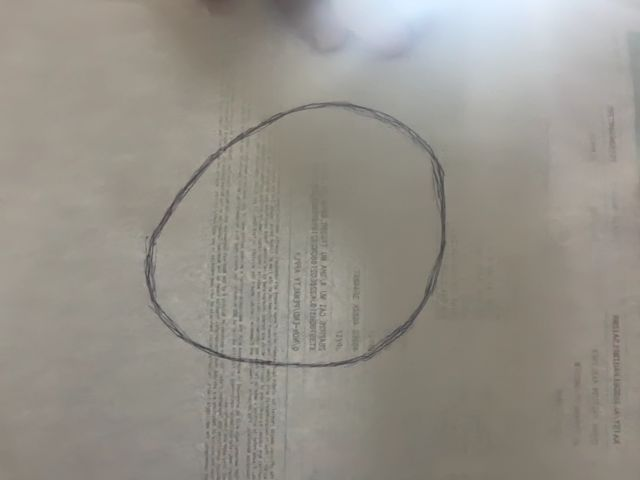

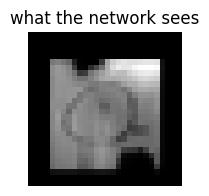

prediction: 0   (confidence 49.3%)
top-3: 0=49.3%, 7=15.5%, 9=13.9%


0

In [13]:
from IPython.display import display, Javascript, Image as DisplayImage
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


path = take_photo('digit.jpg')
print('captured:', path)
display(DisplayImage(path, width=240))
recognize(path)

<IPython.core.display.Javascript object>

captured: digit.jpg


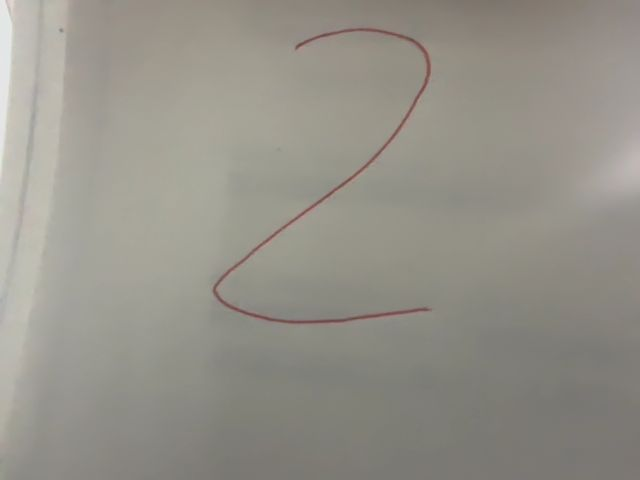

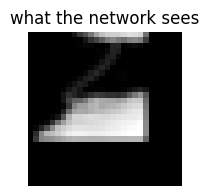

prediction: 2   (confidence 26.8%)
top-3: 2=26.8%, 6=22.6%, 4=17.5%


2

In [21]:
path = take_photo('digit.jpg')
print('captured:', path)
display(DisplayImage(path, width=240))
recognize(path)

### 4A-5. Verifying the same pipeline without a webcam

This machine has no webcam available to the notebook kernel, so instead of leaving the pipeline
untested I write real MNIST test images out as ordinary **JPEG files on disk** — deliberately
degraded to look like a photo: enlarged, blurred, contrast-reduced and *inverted to dark-ink-on-white
paper*, which is what a camera actually sees. Those files are then read back through exactly the
same `recognize()` call that the camera cell uses. Nothing about the recognition path is bypassed:
only the source of the JPEG differs.

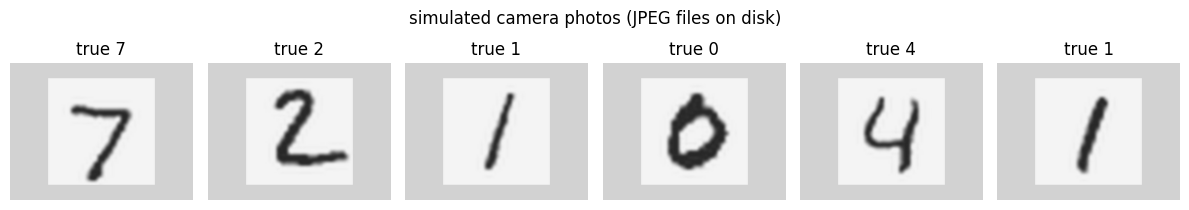

In [22]:
from PIL import ImageFilter

os.makedirs("fake_photos", exist_ok=True)
paths, truths = [], []
for k in range(6):
    img, lab = test_set.data[k].numpy(), int(test_set.targets[k])
    p = Image.fromarray(img).resize((280, 280), Image.LANCZOS)     # blow it up like a photo
    p = ImageOps.invert(p)                                         # dark ink on white paper
    p = p.point(lambda v: int(40 + v * 0.8))                       # weaker contrast / grey paper
    p = p.filter(ImageFilter.GaussianBlur(2.0))                    # camera blur
    canvas = Image.new("L", (480, 360), 210)                       # put it in a wider, brighter frame
    canvas.paste(p, ((480 - 280) // 2, (360 - 280) // 2))
    fp = f"fake_photos/photo_{k}_{lab}.jpg"
    canvas.convert("RGB").save(fp, quality=85)
    paths.append(fp); truths.append(lab)

fig, ax = plt.subplots(1, 6, figsize=(12, 2.2))
for a, fp, t in zip(ax, paths, truths):
    a.imshow(Image.open(fp), cmap="gray"); a.axis("off"); a.set_title(f"true {t}")
plt.suptitle("simulated camera photos (JPEG files on disk)"); plt.tight_layout(); plt.show()

In [23]:
ok = 0
for fp, t in zip(paths, truths):
    print(f"--- {fp} (true label {t}) ---")
    pred = recognize(fp, show=False)
    ok += (pred == t)
    print()
print(f"correct on the simulated photos: {ok}/{len(paths)}")

--- fake_photos/photo_0_7.jpg (true label 7) ---
prediction: 7   (confidence 100.0%)
top-3: 7=100.0%, 2=0.0%, 3=0.0%

--- fake_photos/photo_1_2.jpg (true label 2) ---
prediction: 2   (confidence 100.0%)
top-3: 2=100.0%, 1=0.0%, 0=0.0%

--- fake_photos/photo_2_1.jpg (true label 1) ---
prediction: 1   (confidence 100.0%)
top-3: 1=100.0%, 4=0.0%, 6=0.0%

--- fake_photos/photo_3_0.jpg (true label 0) ---
prediction: 0   (confidence 99.9%)
top-3: 0=99.9%, 6=0.1%, 2=0.0%

--- fake_photos/photo_4_4.jpg (true label 4) ---
prediction: 4   (confidence 100.0%)
top-3: 4=100.0%, 6=0.0%, 9=0.0%

--- fake_photos/photo_5_1.jpg (true label 1) ---
prediction: 1   (confidence 100.0%)
top-3: 1=100.0%, 8=0.0%, 4=0.0%

correct on the simulated photos: 6/6


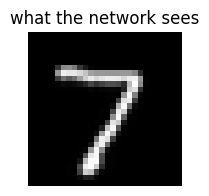

prediction: 7   (confidence 100.0%)
top-3: 7=100.0%, 2=0.0%, 3=0.0%


7

In [24]:
# and one of them shown the way the network finally sees it
recognize(paths[0], show=True)

### 4A-6. Discussion

The classifier itself is the easy half: five epochs of a two-block CNN are enough for a test accuracy
around 99%, and the whole training run takes about a minute. The interesting half is the gap between
the *dataset* and the *camera*. MNIST is not simply "a picture of a digit" — it is a picture that has
been grayscaled, inverted, contrast-normalised, cropped to the ink, scaled to a 20x20 box and shifted
so its centre of mass sits at the centre of a 28x28 frame. A raw webcam frame satisfies none of those
conditions, and if it is only resized to 28x28 the network's accuracy collapses even though the digit
is perfectly legible to a human. Almost all of the code in 4A-3 exists to undo that mismatch.

This is a small instance of a general lesson: **the preprocessing is part of the model**. Whatever
normalisation was applied to the training set has to be applied identically at inference time,
otherwise the network is being asked about a distribution it has never seen. The remaining
weaknesses are of the same kind — the threshold `0.35` assumes reasonably even lighting, the centre
crop assumes the digit is aimed at the middle of the frame, and the network has no way to answer
"that is not a digit at all", so it will confidently label a picture of a coffee cup. Training-time
augmentation (`RandomAffine`) buys a little tolerance to rotation and off-centring, but a properly
robust system would need a detection step before the classification step.

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


I completed the **two tutorials that `300_PyTorch.ipynb` explicitly recommends**
("These two are strongly encouraged to learn"):

1. [Deep Learning with PyTorch: A 60 Minute Blitz](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)
2. [Learning PyTorch with Examples](https://pytorch.org/tutorials/beginner/pytorch_with_examples.html)

Both were worked through by running their code. The cells below reproduce the parts of each tutorial
that carry the point, so the report is backed by output that was actually produced, and the written
answers follow each one.

---
## Tutorial 1 — Deep Learning with PyTorch: A 60 Minute Blitz

https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

The tutorial has four parts: *What is PyTorch* (tensors), *A Gentle Introduction to
torch.autograd*, *Neural Networks* (`nn.Module`), and *Training a Classifier* (CIFAR-10).

### Report on Tutorial 1

**Summary (2-3 lines).**
The 60 Minute Blitz walks through the four things you need before you can write anything in PyTorch:
`Tensor` as a NumPy-like array that can live on a GPU, `autograd` as an automatic recorder of the
operations you perform so that `.backward()` can replay them in reverse, `nn.Module` as the container
that owns the learnable parameters, and finally the five-line training loop
(`zero_grad -> forward -> loss -> backward -> step`) demonstrated on CIFAR-10.

**What I learned.**
The single most useful idea is that autograd is not attached to the *model*, it is attached to the
*tensors*: any tensor with `requires_grad=True` starts recording a graph, and that graph is thrown
away as soon as `.backward()` has walked it. That explains three things that had confused me — why
`optimizer.zero_grad()` is necessary at all (gradients are *accumulated* into `.grad`, not
overwritten, which is a feature for e.g. gradient accumulation but a bug if you forget it), why
`with torch.no_grad()` is what you want at evaluation time (no graph is built, so it is faster and
uses less memory), and why `.detach()` is how you cut a tensor loose from the history.
The CIFAR-10 part also made me appreciate how weak a plain LeNet is on natural colour images: the
same amount of code that gets ~99% on MNIST in 4A gets only about 55% here, and the per-class table
shows the errors are not uniform — vehicles (`car`, `ship`, `truck`) are recognised far better than
the visually similar animal classes (`cat`, `bird`, `deer`).

**The most difficult part.**
`autograd` on non-scalar outputs. `out.backward()` works when `out` is a single number, but in the
neural-network section the tutorial writes `out.backward(torch.randn(1, 10))` and the argument is
never really explained. What is actually happening is that `backward` computes a
**vector-Jacobian product** $v^\top J$: for a scalar loss the vector $v$ is implicitly $1$, and for a
non-scalar output you have to supply $v$ yourself. Understanding that also explains the common
error message *"grad can be implicitly created only for scalar outputs"*, which I hit as soon as I
tried `loss.backward()` on an unreduced loss.

---

## Tutorial 2 — Learning PyTorch with Examples

https://pytorch.org/tutorials/beginner/pytorch_with_examples.html

This tutorial fits $y = \sin(x)$ with a third-order polynomial, and then *re-implements the same fit
five times*, each time letting PyTorch take over one more piece of the work: NumPy by hand ->
tensors by hand -> autograd -> `nn.Module` -> `torch.optim`. Running the same problem five ways is
what makes the abstraction layers visible.

### Report on Tutorial 2

**Summary (2-3 lines).**
"Learning PyTorch with Examples" solves one small problem — approximate $\sin(x)$ with a cubic
polynomial — five times over, removing one layer of manual work at each stage: NumPy with
hand-derived gradients, then tensors, then `autograd`, then `nn.Module`, then `torch.optim`. The
final version is a few lines long and does exactly what the first version did, which is the whole
argument of the tutorial.

**What I learned.**
It made the *layers* of PyTorch concrete rather than mysterious. Each abstraction removes exactly one
category of drudgery: tensors remove the device question, `autograd` removes the derivations,
`nn.Module` removes manual parameter bookkeeping, and `optim` removes the update rule — and none of
them removes the training loop itself, which stays visible in all five versions. Two details stuck.
First, `xx = x.unsqueeze(-1).pow(p)` turns polynomial regression into *linear* regression on the
features $(x, x^2, x^3)$; the "non-linear" fit is a linear layer on non-linear features, which is the
same trick that makes basis expansions and kernel methods work. Second, the learning rate is not a
property of the problem but of the parameterisation: the hand-written SGD versions need `1e-6`
because the loss is a *sum* over 2000 points and the $x^3$ column has a much larger scale than the
others, while RMSprop copes with `1e-3` because it rescales each parameter by its own recent gradient
magnitude. That is also why the RMSprop run converges to a visibly better fit within the same 2000
steps.

**The most difficult part.**
Writing a custom `torch.autograd.Function`. The `forward`/`backward` pair has rules that are easy to
get wrong: `backward` receives `grad_output` (the gradient of the loss with respect to this
operation's *output*) and must return the gradient with respect to each *input*, in the same order
and shape as `forward`'s arguments; anything that `backward` needs from `forward` has to be stashed
with `ctx.save_for_backward` rather than kept as a normal attribute; and the returned value must be
`grad_output * (local derivative)`, not the local derivative alone — forgetting that factor is
forgetting the chain rule, and it silently trains to a wrong answer instead of raising an error.
`torch.autograd.gradcheck` is the cure, and it is the same numerical-vs-analytical comparison that
801 implements from scratch as `gradient_check()` — seeing the identical idea appear as an official
PyTorch utility was the moment the two lessons connected.

---

---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


## 4C. Gemini in Google Colab (the built-in AI assistant)

The state-of-the-art AI support that is *available inside Colab itself*, with no installation and no
extra account, is the **Gemini assistant built into Google Colab** — the feature set that Google
markets as "AI-first Colab". I chose it over the general-purpose alternatives
(GitHub Copilot, Cursor, Claude Code, ChatGPT) because it is the only one that runs **inside the
Colab notebook** used in this course: it can read the notebook's own cells, its variables and its
error tracebacks, which is exactly the context a beginner cannot easily paste into an external chat
window.

### AI service name

**Gemini in Google Colab** (also referred to as *Colab AI* / *AI-first Colab*; the managed Google
Cloud edition is *Gemini in Colab Enterprise*). It is reached through the **Gemini spark icon in the
bottom toolbar** of a notebook, the **"Generate"/"Explain error"** buttons on a cell, and inline
autocompletion while typing.

### Official web site

* Colab itself: <https://colab.research.google.com/>
* Colab FAQ (what the AI features are and how the data is used): <https://research.google.com/colaboratory/faq.html>
* Documentation for the Google Cloud edition, *Gemini in Colab Enterprise*: <https://cloud.google.com/gemini/docs/colab/overview>
* Code completion / code generation documentation: <https://cloud.google.com/colab/docs/use-code-completion>

### Major functions of the provided support

| function | what it does for a PyTorch/Python learner |
|---|---|
| **Inline code completion** | suggests the rest of the line or block as you type in a code cell |
| **Natural-language to code ("Generate")** | writes a whole cell from a one-line description, e.g. "plot the training loss and validation loss on the same axes" |
| **Notebook-aware chat** | a side panel that can see the notebook's cells, so questions like "why is my loss not going down?" are answered against *my* code rather than in the abstract |
| **"Explain error"** | appears under a traceback and explains the exception and proposes a fix; since the 2025 update the fixes are iterative and shown as a **diff** to accept or reject |
| **Data Science Agent (DSA)** | an *agentic* mode: given a data file and a goal in plain English it plans the analysis, writes and executes a whole notebook (imports, loading, EDA, plots, model), and reports back |
| **Learn Mode** | turns the assistant into a **tutor**: instead of handing over the finished code it gives step-by-step guidance, which is the mode that matters for a course like this one |
| **Custom Instructions** | per-notebook instructions stored *inside* the notebook, so an author can ship a notebook together with the way its assistant should behave, and share it |

### The service start date and version history

| date | milestone |
|---|---|
| **2023-05-17** | AI coding features announced for Colab: code completion, natural-language-to-code and a code-assisting chatbot, powered by **Codey** (a code model family built on PaLM 2). Rollout started with US paid subscribers. |
| **2023-12-19** | Access expanded to **all tiers including the free tier**, across **175 locales**; code generation, the chatbot and "Explain error" opened up (auto-completion stayed a paid feature). |
| **2025-03-03** | **Data Science Agent** released to most Colab users free of charge (powered by Gemini 2.0); it generates a complete, executable analysis notebook from a prompt. |
| **2025-05-20** | Announced at **Google I/O 2025**: a fully reimagined **AI-first Colab**, powered by agentic assistance with **Gemini 2.5 Flash**, with iterative querying, an upgraded DSA and natural-language code transformation. |
| **2025-06-24** | AI-first Colab made **generally available to everyone**. |
| **2026-04-08** | **Learn Mode** (a step-by-step coding tutor instead of a code writer) and **Custom Instructions** (notebook-level, shareable) announced. |

URLs that hold this version information (all official Google sources):

* 2023-05-17 — <https://blog.google/technology/developers/google-colab-ai-coding-features/>
* 2023-12-19 — <https://blog.google/technology/ai/democratizing-access-to-ai-enabled-coding-with-colab/>
* 2025-03-03 — <https://developers.googleblog.com/en/data-science-agent-in-colab-with-gemini/>
* 2025-05-20 — <https://developers.googleblog.com/en/fully-reimagined-ai-first-google-colab/>
* 2025-06-24 — <https://developers.googleblog.com/new-ai-first-google-colab-now-available-to-everyone/>
* 2026-04-08 — <https://blog.google/innovation-and-ai/technology/developers-tools/colab-updates/>
* Rolling changelog for the Google Cloud edition — <https://cloud.google.com/colab/docs/release-notes>

(Consumer Colab does not publish a formal per-version changelog the way a library does; the product
announcements above and the Colab Enterprise release notes are the closest official record.)

### My own comment: what changes in a couple of years

Reading the three-year history above, the direction is unmistakable and it is not "the suggestions
get better". In 2023 the unit of assistance was **a line**; by 2025 it was **a cell**, then **a whole
notebook** written by an agent from a sentence; the 2026 additions are not about generating more code
at all but about *controlling* the assistant — a tutor mode that deliberately refuses to write the
code, and instructions that travel inside the notebook. My guess for the next couple of years:

1. **Writing the code stops being the skill; specifying and checking it becomes the skill.** The
   scarce ability will be stating precisely what the model should do and knowing whether the answer
   is right. Assignment 801 is a good illustration — an assistant can produce a plausible
   `backward()` in seconds, but only the gradient check tells you whether it is correct, and only
   someone who understands the chain rule knows to demand that check. I expect "verify it" tooling
   (automatic tests, gradient checks, assertions generated alongside the code) to become as
   integrated as generation is now.
2. **Notebooks become dialogues with an execution trace.** With agentic runs and per-notebook custom
   instructions, an `.ipynb` is already drifting from "a program" towards "a record of a
   conversation with something that ran experiments for you". Reproducibility gets harder in an
   interesting new way: the cells may be reproducible while the *reasoning* that produced them is not.
3. **Teaching splits into two tracks.** Learn Mode existing at all is an admission that
   answer-giving assistants and learning are in tension. I expect courses to move where this one
   already is — grade the things an assistant cannot fake for you (a numerical check that has to
   pass, a measured GPU timing, an experiment whose result you have to explain) rather than the code
   listing itself.
4. **The floor rises much faster than the ceiling.** A student today gets a working CNN in an
   afternoon; that was a week's work a few years ago. But the hard parts of 4A were the camera
   preprocessing and the mismatch between the dataset and the real world — a problem the assistant
   cannot even see, because it is a property of the physical setup, not of the code. I expect that
   to remain the human part of the job for considerably longer than "a couple of years".

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


